In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from typing import Optional, Type, Union
from scipy.interpolate import CubicSpline
import time

#few imports
from few.trajectory.inspiral import EMRIInspiral #function to generate trajectories
from few.trajectory.ode.base import ODEBase #superclass for defining modified flux trajectories
from few.trajectory.ode.flux import KerrEccEqFlux #Adiabatic KerrEccEq base trajectory class

from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum
from few.utils.modeselector import ModeSelector

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)

##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux #trajectory module
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################

from few.waveform.base import SphericalHarmonicWaveformBase #generic waveform generation class
from few.utils.baseclasses import SphericalHarmonic, KerrEccentricEquatorial, ParallelModuleBase, BackendLike

from few.utils.constants import YRSID_SI

from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )

use_gpu = False #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself.

In [2]:
if False:
    from sympy.parsing.mathematica import parse_mathematica
    
    with open("/home/shubham/SuperKludge/version0.2/dLdtH.m", "r") as file:
        math_expr = file.read()
    
    sympy_expr = parse_mathematica(math_expr)
    #print(sympy_expr)

In [3]:
# define parameters
m1 = 1e6
m2 = 1e1
a = 0.9
e0 = 0.1 #must be >> 0.0. SuperKludge returns an error if e < 0.01 at any point along the trajectory.
Y0 = 1.0
dist = 1.0
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
Phi_phi0 = 0.1
Phi_theta0 = 0.2
Phi_r0 = 0.3
dt = 10.0
T = 1.0

#initializing trajectories
start = time.time()
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
print(time.time() - start)

chi2 = 0.9 #dimensionless secondary spin
evolve_1PA = True
evolve_primary = True
evolve_2PA = True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

p0 = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, Y0, *add_args]) + 0.5

print('p0: ', p0)

10.482911586761475


/media/shubham/Ubuntu-HDD/College/PhD/Projects/SuperKludge/FastEMRIWaveforms-Soton-Hackathon-2025/src/few/trajectory/ode/flux.py:662: UserWarning: Flux at horizon for primary evolution are PN-approximated and may be unsuitable.
  warnings.warn("Flux at horizon for primary evolution are PN-approximated and may be unsuitable.")
/media/shubham/Ubuntu-HDD/College/PhD/Projects/SuperKludge/FastEMRIWaveforms-Soton-Hackathon-2025/src/few/trajectory/ode/flux.py:662: UserWarning: Flux at horizon for primary evolution are PN-approximated and may be unsuitable.
  warnings.warn("Flux at horizon for primary evolution are PN-approximated and may be unsuitable.")


p0:  7.661724496166742


0.03464984893798828
0.02503061294555664


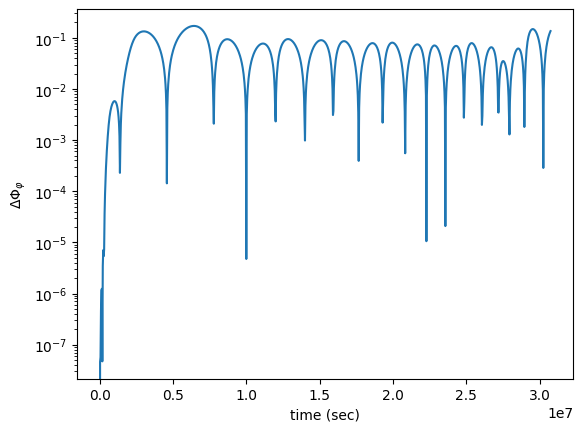

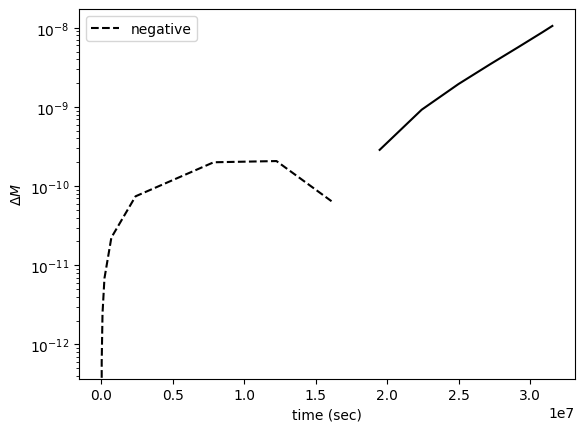

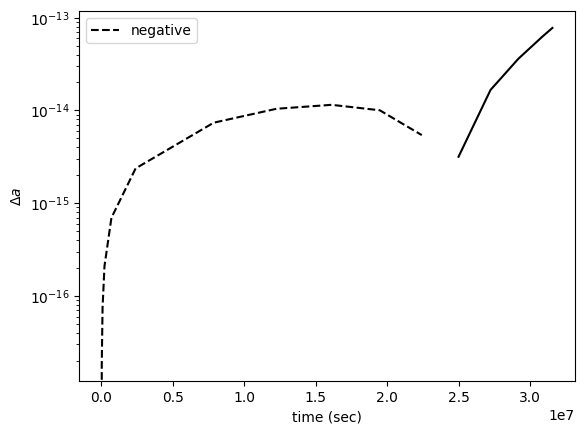

In [4]:
#primary evolution True
start = time.time()
evolve_1PA = False
evolve_primary = True
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t1, p1, e1, x1, pp1, pt1, pr1, delta_M1, delta_a1 = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt)
print(time.time() - start)

#primary evolution False
start = time.time()
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t2, p2, e2, x2, pp2, pt2, pr2, delta_M2, delta_a2 = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt)
print(time.time() - start)

t = np.linspace(max(t1[0],t2[0]),min(t2[-2],t1[-2]),1000) #evolve only to the smaller of the two second last time points.
pp1 = CubicSpline(t1,pp1)(t)
pp2 = CubicSpline(t2,pp2)(t)

plt.plot(t,np.abs(pp2-pp1))
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta\Phi_{\varphi}$')
plt.yscale('log')
#plt.savefig('phase_diff_primary_evolution.png',transparent=False)
plt.show()

plt.plot(t1[delta_M1>0.0],(delta_M1)[delta_M1>0.0],color='k',linestyle='-')
plt.plot(t1[delta_M1<=0.0],np.abs(delta_M1)[delta_M1<=0.0],color='k',linestyle='--',label='negative')
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta M$')
plt.yscale('log')
plt.legend()
#plt.savefig('primary_mass_evolution.png',transparent=False)
plt.show()

plt.plot(t1[delta_a1>0.0],(delta_a1)[delta_a1>0.0],color='k',linestyle='-')
plt.plot(t1[delta_a1<=0.0],np.abs(delta_a1)[delta_a1<=0.0],color='k',linestyle='--',label='negative')
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta a$')
plt.yscale('log')
plt.legend()
#plt.savefig('primary_spin_evolution.png',transparent=False)
plt.show()

#p0 = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[M, mu, a, e0, Y0, chi2, evolve_primary, evolve_2PA])

In [5]:
#waveform setup

sum_kwargs=dict(pad_output=False, odd_len=True)

start = time.time()
wave = GenerateEMRIWaveform(SuperKludgeWaveform,sum_kwargs=sum_kwargs, return_list=True)
print(time.time()-start)

77.0966808795929


In [ ]:
evolve_1PA = True
evolve_primary = True
evolve_2PA = True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

start = time.time()
for _ in range(10):
    waveform = wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
print((time.time()-start)/10)

/media/shubham/Ubuntu-HDD/College/PhD/Projects/SuperKludge/FastEMRIWaveforms-Soton-Hackathon-2025/src/few/trajectory/ode/flux.py:662: UserWarning: Flux at horizon for primary evolution are PN-approximated and may be unsuitable.
  warnings.warn("Flux at horizon for primary evolution are PN-approximated and may be unsuitable.")


In [ ]:
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

wave_null = wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)

In [ ]:
time_steps = np.linspace(0.0,T*YRSID_SI,len(cp.asnumpy(cp.asarray(waveform))[0]))

fig, axs = plt.subplots(1,2,figsize=(20,7),sharey=True)

if use_gpu:
    waveform = waveform.get()
    wave_null = wave_null.get()
    
axs[0].plot(time_steps[:1000],waveform[0][:1000])
axs[0].plot(time_steps[:1000],wave_null[0][:1000])

axs[1].plot(time_steps[-1000:],waveform[0][-1000:])
axs[1].plot(time_steps[-1000:],wave_null[0][-1000:])

plt.savefig('wave_snaps.png',transparent=False)
plt.show()